In [ ]:

import os
import requests
from datetime import datetime
import re
import json  # Para exportar el resumen
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [20]:

cur_dir = os.getcwd()
print(cur_dir)
#C:\Users\FERNANDO\Documents\DS_2025\lecture_3\tarea_2 , este es el target 
#print(cur_dir)
#cur_dir=os.chdir(r"..\Documents\DS_2025\lecture_3\tarea_2") # el directorio ya esta cambiado
print(cur_dir)

c:\Users\FERNANDO\Documents\DS_2025\lecture_3\tarea_2
c:\Users\FERNANDO\Documents\DS_2025\lecture_3\tarea_2


In [ ]:

# Configuración
BASE_DIR = os.path.join(os.getcwd(), "codeforces_contests")
os.makedirs(BASE_DIR, exist_ok=True)

# 1. Obtener lista de concursos
def get_contests():
    url = "https://codeforces.com/api/contest.list"
    response = requests.get(url)
    return response.json().get("result", [])

# 2. Filtrar concursos (Julio-Diciembre 2024 + keywords)
def filter_contests(contests):
    start_date = datetime(2024, 7, 1).timestamp()
    end_date = datetime(2024, 12, 31, 23, 59, 59).timestamp()
    keywords = ["Hello", "Round", "Good Bye"]
    
    return [
        contest for contest in contests
        if contest.get("startTimeSeconds") 
        and start_date <= contest["startTimeSeconds"] <= end_date
        and any(k in contest.get("name", "") for k in keywords)
    ]

# 3. Obtener datos adicionales de cada concurso
def fetch_contest_data(contest_id):
    endpoints = {
        "standings": f"https://codeforces.com/api/contest.standings?contestId={contest_id}",
        "ratedList": f"https://codeforces.com/api/user.ratedList?activeOnly=true&contestId={contest_id}",
        "status": f"https://codeforces.com/api/contest.status?contestId={contest_id}",
        "ratingChanges": f"https://codeforces.com/api/contest.ratingChanges?contestId={contest_id}"
    }
    
    data = {}
    for name, url in endpoints.items():
        try:
            response = requests.get(url)
            data[name] = response.json().get("result", {})
            time.sleep(0.5)  # Evitar rate-limiting
        except Exception as e:
            print(f"Error en {name}: {e}")
            data[name] = None
    
    return data

# Procesamiento principal
all_contests = get_contests()
filtered_contests = filter_contests(all_contests)

for contest in filtered_contests:
    contest_id = contest["id"]
    contest_name = re.sub(r'[\\/*?:"<>|]', "", contest.get("name", "")).strip().replace(" ", "_")
    contest_dir = os.path.join(BASE_DIR, f"{contest_id}_{contest_name}")
    os.makedirs(contest_dir, exist_ok=True)
    
    # Guardar metadata básica
    with open(os.path.join(contest_dir, "contest_info.json"), "w") as f:
        json.dump(contest, f, indent=4)
    
    # Obtener y guardar datos adicionales
    contest_data = fetch_contest_data(contest_id)
    for data_type, data in contest_data.items():
        if data:
            with open(os.path.join(contest_dir, f"{data_type}.json"), "w") as f:
                json.dump(data, f, indent=4)

print(f"Proceso completado. {len(filtered_contests)} concursos procesados.")

Proceso completado. 57 concursos procesados.


# 📊 **Análisis de Concursos Codeforces**  
*(Julio - Diciembre 2024)*  

---

## 🌐 **Endpoints de la API Usados**  

### **1. Lista de Concursos**  
`GET` `https://codeforces.com/api/contest.list`  

```json
{
  "id": 123,
  "name": "Codeforces Round #666",
  "startTimeSeconds": 1735687200,
  "durationSeconds": 7200
}
``` 
### **2. Standings del Concurso**  
`GET` `https://codeforces.com/api/contest.standings?contestId={id}`
```json
{
  "problems": [
    {"index": "A", "name": "Problem A", "rating": 800}
  ],
  "rows": [
    {
      "party": {"members": [{"handle": "usuario1"}]},
      "problemResults": [
        {"points": 1, "bestSubmissionTimeSeconds": 1200}
      ]
    }
  ]
}
``` 
### **3. Submissions del Concurso**  
`GET` `https://codeforces.com/api/contest.status?contestId={id}`
```json
{
  "id": 456789,
  "programmingLanguage": "GNU C++20",
  "verdict": "OK",
  "relativeTimeSeconds": 1200
}
```

### **4. Lista de Usuarios Clasificados**  
`GET` `https://codeforces.com/api/user.ratedList`
```json
{
  "handle": "usuario1",
  "rating": 2400,
  "maxRating": 2500,
  "country": "Perú"
}
```
### **5. Cambios de Rating **  
`GET` `https://codeforces.com/api/contest.ratingChanges?contestId={id}t`
```json
{

  "handle": "usuario1",
  "oldRating": 2400,
  "newRating": 2450

}
```

In [47]:
base_dir = os.getcwd()
contest_dir = os.path.join(base_dir, "codeforces_contests")
print(contest_dir)
d_compro=[]#esta lista es una dummy, 1 si es que se tienen 5 archivos en el directorio de cada uno de los concursos
missing_rating_changes=[]
for folder in os.listdir(contest_dir):
    newdir=os.path.join(contest_dir,folder)
    if(len(os.listdir(newdir)))==5:
        d_compro+=[0]
    else:
        d_compro+=[1]
        missing_rating_changes+=[folder]
        print(folder)
    #print(type(folder)) # para visualización de las carpetas que se encuentran en este directorio
print(d_compro)


c:\Users\FERNANDO\Documents\DS_2025\lecture_3\tarea_2\codeforces_contests
2009_Codeforces_Round_971_(Div._4)
2010_Testing_Round_19_(Div._3)
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
def final_optimized_dataframe(contest_folder):
    """Versión definitiva con garantía de metadatos"""
    start_time = time.time()
    contest_path = os.path.join('codeforces_contests', contest_folder)
    
    #  Carga eficiente de archivos
    def load_json(file):
        filepath = os.path.join(contest_path, f"{file}.json")
        if not os.path.exists(filepath):
            return None
        with open(filepath) as f:
            return json.load(f)
    
    # Carga en paralelo con manejo de errores
    with ThreadPoolExecutor() as executor:
        contest_info = executor.submit(load_json, 'contest_info').result() or {}
        standings = executor.submit(load_json, 'standings').result() or {'rows': [], 'problems': []}
        submissions = executor.submit(load_json, 'status').result() or []
        rated_users = executor.submit(load_json, 'ratedList').result() or []
    
    # Diccionario de metadatos robusto
    user_metadata = {}
    for user in rated_users:
        if 'handle' in user:
            user_metadata[user['handle']] = {
                'country': user.get('country'),
                'city': user.get('city'),
                'rating': user.get('rating'),
                'maxRating': user.get('maxRating')
            }
    
    #  Procesamiento de problemas
    problems = pd.DataFrame(standings.get('problems', []))
    prob_count = len(problems)
    problem_indices = [prob['index'] for prob in standings.get('problems', [])]
    
    #  Mapeo de lenguajes optimizado
    language_data = {}
    for sub in submissions:
        if sub.get('verdict') == 'OK':
            handle = sub['author']['members'][0]['handle'] if sub['author'].get('members') else None
            if handle:
                problem_idx = sub['problem']['index']
                language_data[(handle, problem_idx)] = sub.get('programmingLanguage')
    
    # Construcción del DataFrame
    records = []
    for row in standings.get('rows', []):
        if not row['party'].get('members'):
            continue
            
        handle = row['party']['members'][0]['handle']
        metadata = user_metadata.get(handle, {})
        
        # Datos base
        record = {
            'author_handle': handle,
            'contest_id': contest_info.get('id'),
            'contest_name': contest_info.get('name'),
            'contest_start_time': contest_info.get('startTimeSeconds'),
            'rating_achieved': 0,
            **metadata  # Metadatos del usuario
        }
        
        # Datos por problema
        for i, (prob_idx, prob_result) in enumerate(zip(problem_indices, row['problemResults']), 1):
            solved = prob_result['points'] > 0
            rt = prob_result.get('bestSubmissionTimeSeconds')
            
            record.update({
                f'finished_{i}': solved,
                f'relative_time_{i}': rt,
                f'rating_{i}': problems.loc[i-1, 'rating'] if i-1 < len(problems) else None,
                f'{i}_language': language_data.get((handle, prob_idx))
            })
            
            if solved:
                record['rating_achieved'] += problems.loc[i-1, 'rating'] if i-1 < len(problems) else 0
        
        records.append(record)
    
    df = pd.DataFrame(records)
    
    # Cálculo de time_to_answer
    for i in range(1, prob_count + 1):  
        df[f'time_to_answer_{i}'] = df[f'relative_time_{i}'] - df.get(f'relative_time_{i-1}', 0) if i > 1 else df[f'relative_time_{i}']
    
    print(f"Procesado {contest_folder} en {time.time()-start_time:.2f} segundos")
    return df

In [ ]:
# Procesar un concurso
contest_folder = "2009_Codeforces_Round_971_(Div._4)"
df = final_optimized_dataframe(contest_folder)

# Verificar metadatos
print("\nVerificación de metadatos:")
print(f"Usuarios con country: {df['country'].notna().sum()}") # me asuste de que al imprimir el head de la data me salian muchos NAnS
print(f"Usuarios con rating: {df['rating'].notna().sum()}")
print("\nEjemplo de datos:")
print(df[['author_handle', 'country', 'rating', 'maxRating']])


Procesado 2009_Codeforces_Round_971_(Div._4) en 11.38 segundos

Verificación de metadatos:
Usuarios con country: 4067
Usuarios con rating: 7904

Ejemplo de datos:
           author_handle country  rating  maxRating
0               dorazmon     NaN     NaN        NaN
1              bluechips     NaN     NaN        NaN
2                 714285     NaN     NaN        NaN
3              fzitb7912     NaN     NaN        NaN
4         GrievousTurtle     NaN     NaN        NaN
...                  ...     ...     ...        ...
29229           Manoj_04     NaN     NaN        NaN
29230      Ankitdhanghar     NaN     NaN        NaN
29231  madhucharitha2005     NaN     NaN        NaN
29232      chinni123_567     NaN     NaN        NaN
29233              dr0bi    None   809.0     1070.0

[29234 rows x 4 columns]


In [ ]:
# Procesamiento de todos los files
contest_folders = [f for f in os.listdir('codeforces_contests') 
                  if os.path.isdir(os.path.join('codeforces_contests', f))]

for folder in contest_folders:  
    df = optimized_create_unified_dataframe(folder)
    df.to_csv(f"{folder}_processed.csv", index=False)

Procesado 1983_Codeforces_Round_956_(Div._2)_and_ByteRace_2024 en 6.72 segundos
Procesado 1988_Codeforces_Round_958_(Div._2) en 6.85 segundos
Procesado 1990_Codeforces_Round_960_(Div._2) en 7.22 segundos
Procesado 1991_Pinely_Round_4_(Div._1_+_Div._2) en 8.62 segundos
Procesado 1992_Codeforces_Round_957_(Div._3) en 14.31 segundos
Procesado 1993_Codeforces_Round_963_(Div._2) en 9.40 segundos
Procesado 1994_Codeforces_Round_959_sponsored_by_NEAR_(Div._1_+_Div._2) en 7.91 segundos
Procesado 1995_Codeforces_Round_961_(Div._2) en 7.22 segundos
Procesado 1996_Codeforces_Round_962_(Div._3) en 10.70 segundos
Procesado 1997_Educational_Codeforces_Round_168_(Rated_for_Div._2) en 8.30 segundos
Procesado 1998_Codeforces_Round_965_(Div._2) en 8.52 segundos
Procesado 1999_Codeforces_Round_964_(Div._4) en 18.85 segundos
Procesado 2000_Codeforces_Round_966_(Div._3) en 13.21 segundos
Procesado 2001_Codeforces_Round_967_(Div._2) en 7.30 segundos
Procesado 2002_EPIC_Institute_of_Technology_Round_August_2

In [95]:


#  Definir la ruta CORRECTA (usando raw string para evitar escapes)
folder_path = os.getcwd()

#  Listar TODOS los archivos CSV (sin filtro estricto por si acaso)
all_csv_files = [file for file in os.listdir(folder_path) 
                if file.endswith('.csv')]  # Captura cualquier CSV

#  Validación crítica
if not all_csv_files:
    raise ValueError("No hay archivos CSV en la carpeta. Revisa que los archivos estén ahí.")

print(f"📂 Archivos encontrados ({len(all_csv_files)}):")
for file in all_csv_files[:5]:  # Muestra los primeros 5 para verificar
    print(f"→ {file}")

#  Concatenar con manejo de memoria (por si son grandes)
final_merged_df = pd.concat(
    [pd.read_csv(os.path.join(folder_path, file)) for file in all_csv_files],
    ignore_index=True
)

#  Guardar el merge (en la misma carpeta por defecto)
output_path = os.path.join(folder_path, "FINAL_MERGED.csv")
final_merged_df.to_csv(output_path, index=False)



print(f" Guardado en: {output_path}")

📂 Archivos encontrados (58):
→ 1983_Codeforces_Round_956_(Div._2)_and_ByteRace_2024_processed.csv
→ 1988_Codeforces_Round_958_(Div._2)_processed.csv
→ 1990_Codeforces_Round_960_(Div._2)_processed.csv
→ 1991_Pinely_Round_4_(Div._1_+_Div._2)_processed.csv
→ 1992_Codeforces_Round_957_(Div._3)_processed.csv


C:\Users\FERNANDO\AppData\Local\Temp\ipykernel_24556\3169606188.py:18: DtypeWarning: Columns (20,24,28) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(os.path.join(folder_path, file)) for file in all_csv_files],
C:\Users\FERNANDO\AppData\Local\Temp\ipykernel_24556\3169606188.py:18: DtypeWarning: Columns (24,28,32) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(os.path.join(folder_path, file)) for file in all_csv_files],
C:\Users\FERNANDO\AppData\Local\Temp\ipykernel_24556\3169606188.py:18: DtypeWarning: Columns (32,36) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(os.path.join(folder_path, file)) for file in all_csv_files],
C:\Users\FERNANDO\AppData\Local\Temp\ipykernel_24556\3169606188.py:18: DtypeWarning: Columns (21,25,29,32,44,47,48,51,54,57,59,62) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(os.path.join(folder_p

 Guardado en: c:\Users\FERNANDO\Documents\DS_2025\lecture_3\tarea_2\FINAL_MERGED.csv


In [88]:
final_merged_df

,author_handle,contest_id,contest_name,contest_start_time,rating_achieved,finished_1,relative_time_1,rating_1,1_language,finished_2,...,finished_10,relative_time_10,rating_10,10_language,time_to_answer_10,finished_11,relative_time_11,rating_11,11_language,time_to_answer_11
0,_worst_,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,1720362900,12900,True,5835.0,800,C++20 (GCC 13-64),True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Shirayuki_Noa,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,1720362900,9900,True,113.0,800,C++14 (GCC 6-32),True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cynNYCal,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,1720362900,9900,True,79.0,800,C++20 (GCC 13-64),True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cocae,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,1720362900,9900,True,215.0,800,C++17 (GCC 7-32),True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,_furina,1983,Codeforces Round 956 (Div. 2) and ByteRace 2024,1720362900,9900,True,168.0,800,C++17 (GCC 7-32),True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892909,anjanmahapatra10,2053,Good Bye 2024: 2025 is NEAR,1735396500,0,False,NaN,800,NaN,False,...,False,NaN,3500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
892910,markodesu,2053,Good Bye 2024: 2025 is NEAR,1735396500,0,False,NaN,800,NaN,False,...,False,NaN,3500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
892911,janu25,2053,Good Bye 2024: 2025 is NEAR,1735396500,0,False,NaN,800,NaN,False,...,False,NaN,3500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
892912,Meahhal24,2053,Good Bye 2024: 2025 is NEAR,1735396500,0,False,NaN,800,NaN,False,...,False,NaN,3500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


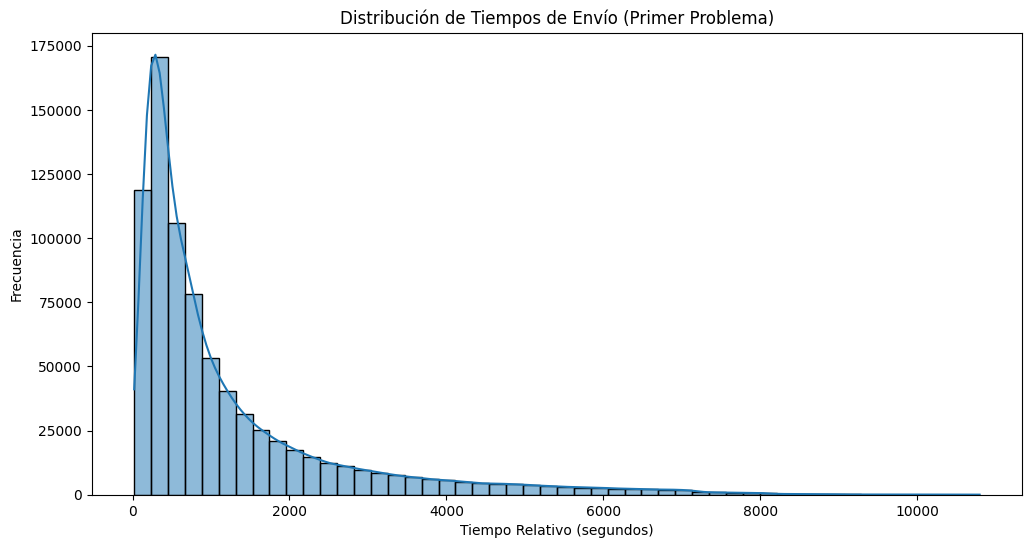

In [ ]:

plt.figure(figsize=(12, 6))
sns.histplot(data=final_merged_df, x='relative_time_1', bins=50, kde=True)
plt.title('Distribución de Tiempos de Envío (Primer Problema)')
plt.xlabel('Tiempo Relativo (segundos)')
plt.ylabel('Frecuencia')
plt.show()

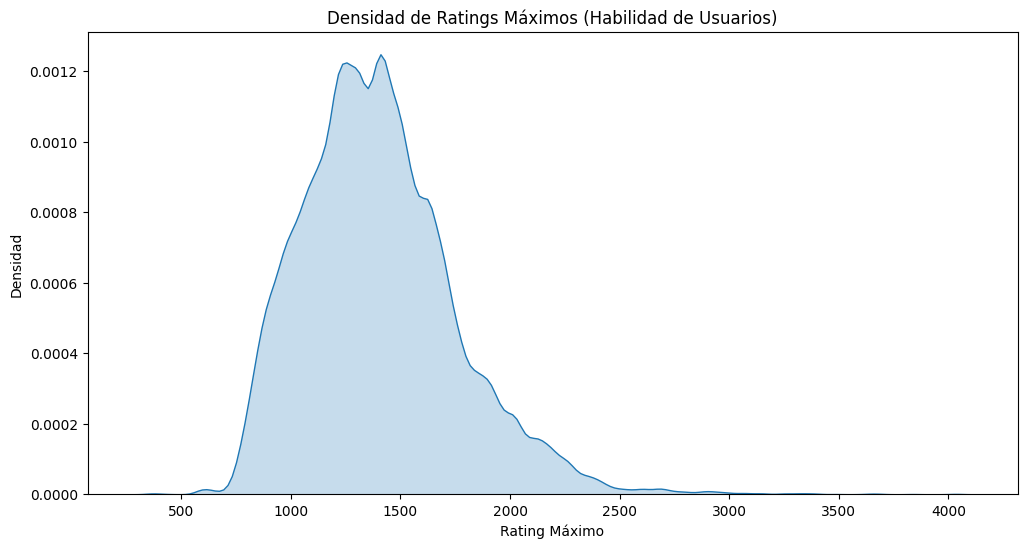

In [90]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=final_merged_df, x='maxRating', fill=True)
plt.title('Densidad de Ratings Máximos (Habilidad de Usuarios)')
plt.xlabel('Rating Máximo')
plt.ylabel('Densidad')
plt.show()

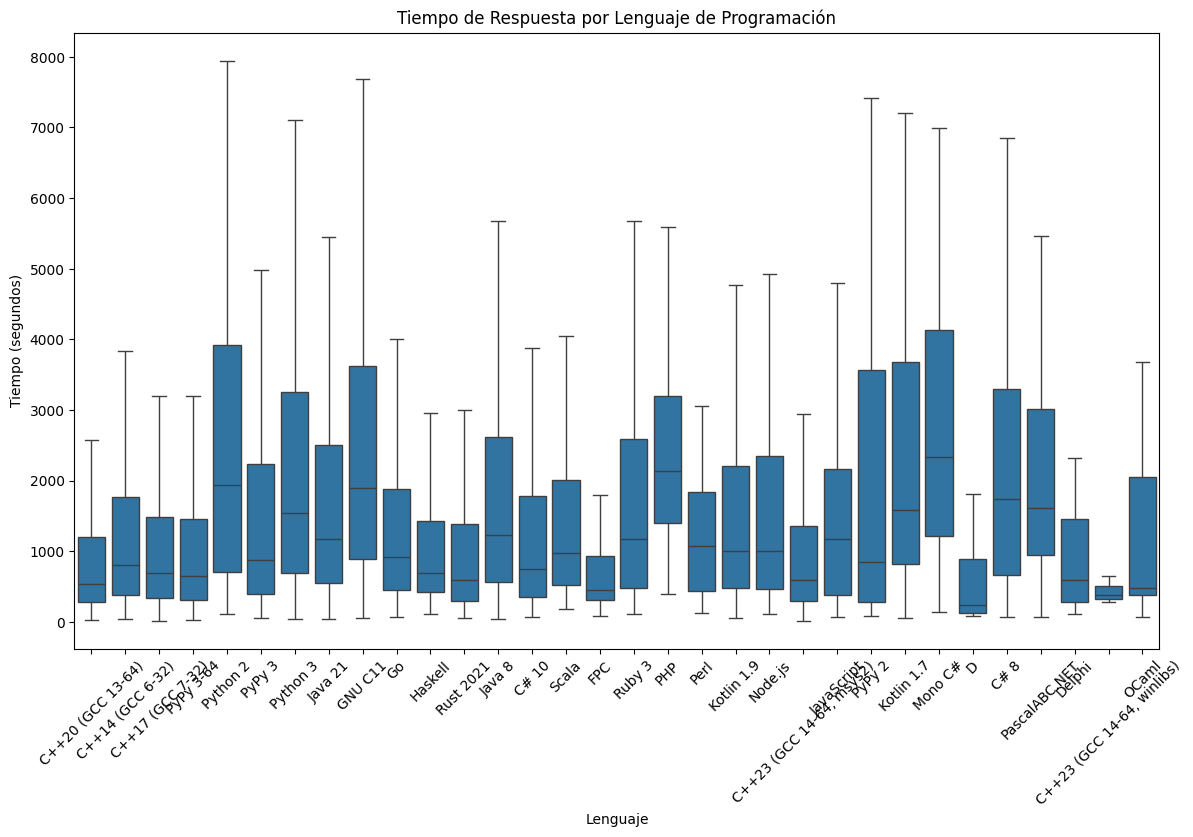

In [92]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=final_merged_df, 
    x='1_language', 
    y='time_to_answer_1',
    showfliers=False  # Oculta outliers para mejor visualización
)
plt.title('Tiempo de Respuesta por Lenguaje de Programación')
plt.xlabel('Lenguaje')
plt.ylabel('Tiempo (segundos)')
plt.xticks(rotation=45)
plt.show()

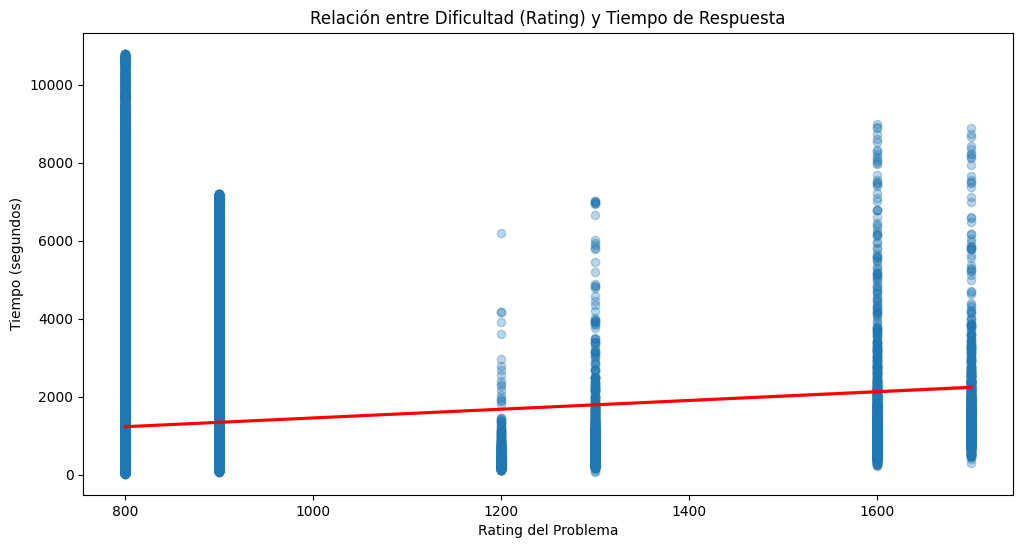

In [93]:
plt.figure(figsize=(12, 6))
sns.regplot(
    data=final_merged_df,
    x='rating_1', 
    y='time_to_answer_1',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Relación entre Dificultad (Rating) y Tiempo de Respuesta')
plt.xlabel('Rating del Problema')
plt.ylabel('Tiempo (segundos)')
plt.show()

<Figure size 1200x600 with 0 Axes>

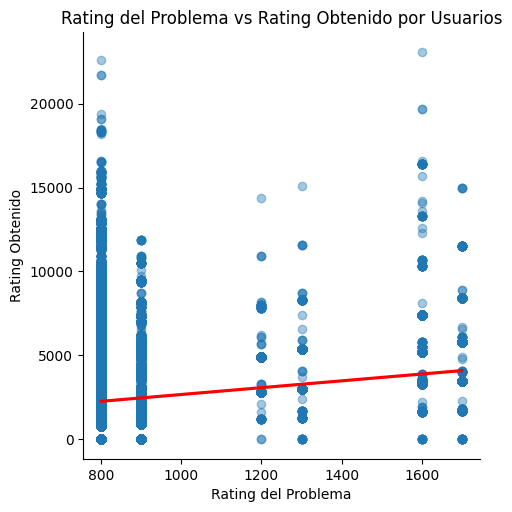

In [94]:
plt.figure(figsize=(12, 6))
sns.lmplot(
    data=final_merged_df,
    x='rating_1', 
    y='rating_achieved',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
plt.title('Rating del Problema vs Rating Obtenido por Usuarios')
plt.xlabel('Rating del Problema')
plt.ylabel('Rating Obtenido')
plt.show()